# Modified Gram-Schmidt: Numerical Stability and Geometric Intuition

In this notebook, we explore the Modified Gram-Schmidt (MGS) algorithm, a more numerically stable alternative to the Classical Gram-Schmidt (CGS) process. We will visualize the geometric process of orthogonalization and demonstrate the breakdown of CGS when dealing with ill-conditioned matrices like the Hilbert matrix.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Ensure we can import from src
sys.path.append(os.path.abspath(os.path.join('..')))

from src.linalg.orthonormalization import modified_gram_schmidt, classical_gram_schmidt
from src.linalg.special_matrices import hilbert_matrix

## 1. The Geometry of Orthogonalization

We start with two non-orthogonal 2D vectors and use MGS to produce an orthonormal basis.

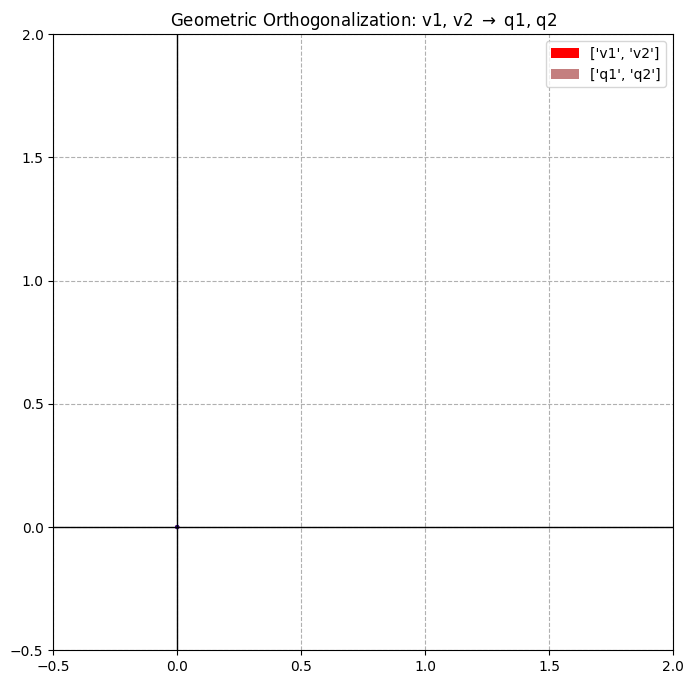

Dot product of q1 and q2: 0.0000000000000002


In [9]:
# Define two non-orthogonal vectors
v1 = np.array([1, 0.5])
v2 = np.array([0.8, 1.2])
A = np.column_stack((v1, v2))

# Apply MGS
Q, R = modified_gram_schmidt(A)
q1, q2 = Q[:, 0], Q[:, 1]

# Plotting
plt.figure(figsize=(8, 8))
origin = np.array([[0, 0], [0, 0]])

plt.quiver(*origin, A[0, :], A[1, :], color=['r', 'b'], scale=1, scale_units='xy', label=['v1', 'v2'])
plt.quiver(*origin, Q[0, :], Q[1, :], color=['darkred', 'darkblue'], scale=1, scale_units='xy', label=['q1', 'q2'], alpha=0.5)

plt.xlim(-0.5, 2)
plt.ylim(-0.5, 2)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.grid(True, linestyle='--')
plt.title(r"Geometric Orthogonalization: v1, v2 $\rightarrow$ q1, q2")
plt.legend()
plt.show()

print(f"Dot product of q1 and q2: {np.dot(q1, q2):.16f}")

## 2. The Stability Proof: MGS vs. CGS

We use the Hilbert matrix, which is notoriously ill-conditioned, to test the numerical stability of both algorithms. A Hilbert matrix $H$ has entries $H_{ij} = \frac{1}{i+j-1}$. As the size of the matrix increases, the vectors become nearly linearly dependent, posing a challenge for Gram-Schmidt.

Classical Gram-Schmidt Orthogonality Error: 5.48e+00
Modified Gram-Schmidt Orthogonality Error:  3.49e-01


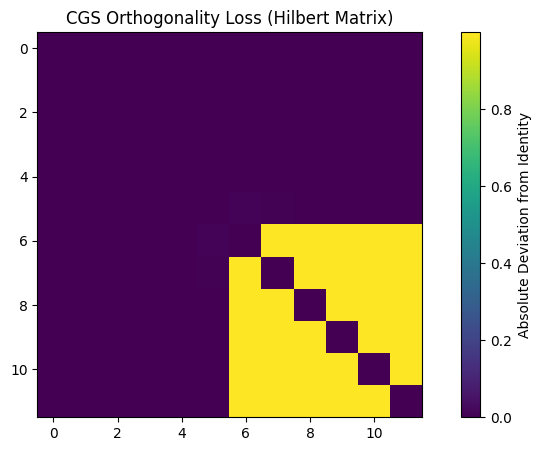

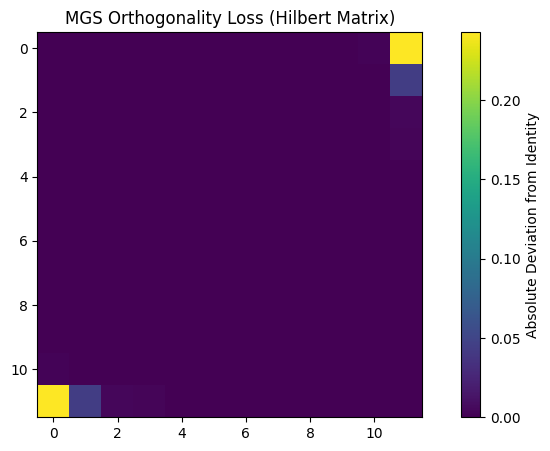

In [10]:
n_size = 10
H = hilbert_matrix(n_size)

Q_cgs, _ = classical_gram_schmidt(H)
Q_mgs, _ = modified_gram_schmidt(H)

# Check loss of orthogonality: ||I - Q^T Q||
err_cgs = np.linalg.norm(np.eye(n_size) - Q_cgs.T @ Q_cgs)
err_mgs = np.linalg.norm(np.eye(n_size) - Q_mgs.T @ Q_mgs)

print(f"Classical Gram-Schmidt Orthogonality Error: {err_cgs:.2e}")
print(f"Modified Gram-Schmidt Orthogonality Error:  {err_mgs:.2e}")

plt.figure(figsize=(10, 5))
plt.imshow(np.abs(np.eye(n_size) - Q_cgs.T @ Q_cgs), cmap='viridis')
plt.colorbar(label='Absolute Deviation from Identity')
plt.title("CGS Orthogonality Loss (Hilbert Matrix)")
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(np.abs(np.eye(n_size) - Q_mgs.T @ Q_mgs), cmap='viridis')
plt.colorbar(label='Absolute Deviation from Identity')
plt.title("MGS Orthogonality Loss (Hilbert Matrix)")
plt.show()

## Narrative: Why Modified Gram-Schmidt?

While Classical Gram-Schmidt is mathematically elegant, it is dangerously unstable in finite-precision arithmetic because it projects the *original* vectors onto the accumulating subspace. Modified Gram-Schmidt, by contrast, orthogonalizes the *remaining* vectors against each new basis vector as it is found, effectively "deflating" the errors at each step. This subtle shift ensures that $Q$ remains much closer to true orthogonality, even when the input matrix is nearly singular.